In [3]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

from joblib import load
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

WP_MODEL_PATH = "wp_model_naive.pkl"

# ==========================================================
# 1. RAW HELPERS
# ==========================================================
def add_winner_loser(df: pl.DataFrame) -> pl.DataFrame:
    final_drives = df.filter(
        pl.col("DriveNumber") == pl.col("DriveNumber").max().over("GameId")
    )

    final_drives = (
        final_drives
        .with_columns(
            (pl.col("EndOffenseScore") > pl.col("EndDefenseScore")).alias("Offense_Won")
        )
        .with_columns(
            pl.when(pl.col("Offense_Won"))
            .then(pl.col("Offense"))
            .otherwise(pl.col("Defense"))
            .alias("winner"),

            pl.when(pl.col("Offense_Won"))
            .then(pl.col("Defense"))
            .otherwise(pl.col("Offense"))
            .alias("loser"),
        )
        .select(["GameId", "winner", "loser"])
    )

    return df.join(final_drives, on="GameId", how="left")


def add_basic_game_state(df: pl.DataFrame) -> pl.DataFrame:
    return (
        df.with_columns(
            (pl.col("Offense") == pl.col("winner")).alias("OffenseWon"),
            (
                60 * (
                    15 * (pl.lit(4) - pl.col("StartPeriod")) +
                    pl.col("StartTime Minutes")
                ) + pl.col("StartTime Seconds")
            ).alias("SecondsRemaining"),
            (pl.col("StartOffenseScore") - pl.col("StartDefenseScore")).alias("ScoreDifferential")
        )
    )


def add_win_probability_and_wp_added(df: pl.DataFrame, wp_model_path: str) -> pl.DataFrame:
    model = load(wp_model_path)

    features = [
        "StartYardline",
        "IsHomeOffense",
        "ScoreDifferential",
        "SecondsRemaining",
    ]

    X = df.select(features).to_numpy()
    wp = model.predict_proba(X)[:, 1]

    df = df.with_columns(pl.Series("win_prob", wp))

    df = df.sort(["GameId", "DriveNumber"]).with_columns(
        pl.col("win_prob").shift(-1).over("GameId").alias("next_wp_raw")
    )

    df = df.with_columns(
        pl.when(pl.col("next_wp_raw").is_null())
        .then(pl.when(pl.col("OffenseWon")).then(1.0).otherwise(0.0))
        .otherwise(pl.col("next_wp_raw"))
        .alias("next_wp")
    )

    df = df.with_columns(
        (pl.col("next_wp") - pl.col("win_prob")).alias("drive_wp_added")
    )

    return df


# ==========================================================
# 2. BUILD ONE ROW PER GAME
# ==========================================================
def build_games(df: pl.DataFrame) -> pl.DataFrame:
    home_teams = (
        df.filter(pl.col("IsHomeOffense") == True)
        .group_by("GameId")
        .agg(pl.col("Offense").first().alias("HomeTeam"))
    )

    away_teams = (
        df.filter(pl.col("IsHomeOffense") == False)
        .group_by("GameId")
        .agg(pl.col("Offense").first().alias("AwayTeam"))
    )

    outcomes = (
        df.group_by("GameId")
        .agg(
            pl.col("winner").first().alias("winner"),
            pl.col("loser").first().alias("loser")
        )
    )

    games = (
        home_teams
        .join(away_teams, on="GameId", how="inner")
        .join(outcomes, on="GameId", how="inner")
        .with_columns(
            (pl.col("winner") == pl.col("HomeTeam")).cast(pl.Int8).alias("HomeWon")
        )
        .sort("GameId")
    )

    return games


def infer_weeks_from_gameid_order(games: pl.DataFrame) -> pl.DataFrame:
    games = games.sort("GameId")

    team_games_played = {}
    inferred_weeks = []

    for row in games.iter_rows(named=True):
        home = row["HomeTeam"]
        away = row["AwayTeam"]

        home_prior = team_games_played.get(home, 0)
        away_prior = team_games_played.get(away, 0)

        week = max(home_prior, away_prior) + 1
        inferred_weeks.append(week)

        team_games_played[home] = home_prior + 1
        team_games_played[away] = away_prior + 1

    return games.with_columns(pl.Series("Week", inferred_weeks))


# ==========================================================
# 3. LOAD YEAR
# ==========================================================
def load_year(year: int) -> pl.DataFrame:
    df = pl.read_csv(f"{year}drives.csv")

    required = [
        "GameId", "DriveNumber", "Offense", "Defense",
        "Yards", "StartYardsToGoal", "EndOffenseScore", "StartOffenseScore",
        "EndDefenseScore", "StartDefenseScore",
        "StartYardline", "IsHomeOffense",
        "StartPeriod", "StartTime Minutes", "StartTime Seconds"
    ]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"{year}drives.csv is missing columns: {missing}")

    df = add_winner_loser(df)
    df = add_basic_game_state(df)
    df = add_win_probability_and_wp_added(df, WP_MODEL_PATH)

    df = df.with_columns(
        (pl.col("EndOffenseScore") - pl.col("StartOffenseScore")).alias("points_added"),
        pl.when(pl.col("StartYardsToGoal") > 0)
          .then((pl.col("Yards") / pl.col("StartYardsToGoal")).clip(0, 1))
          .otherwise(None)
          .alias("yards_pct"),
        pl.lit(year).alias("Season")
    )

    games = build_games(df)
    games = infer_weeks_from_gameid_order(games).select(["GameId", "Week"])
    df = df.join(games, on="GameId", how="left")
    return df


# ==========================================================
# 4. TEAM-GAME STATS
# ==========================================================
def build_team_game_stats(df: pl.DataFrame) -> pl.DataFrame:
    offense_stats = (
        df.group_by(["GameId", "Season", "Week", "Offense"])
        .agg(
            pl.mean("Yards").alias("off_yards"),
            pl.mean("points_added").alias("off_points"),
            pl.mean("yards_pct").alias("off_yards_pct"),
            pl.mean("drive_wp_added").alias("off_wp"),
            pl.len().alias("off_n_drives"),
        )
        .rename({"Offense": "Team"})
    )

    defense_stats = (
        df.group_by(["GameId", "Season", "Week", "Defense"])
        .agg(
            pl.mean("Yards").alias("def_yards_allowed"),
            pl.mean("points_added").alias("def_points_allowed"),
            pl.mean("yards_pct").alias("def_yards_pct_allowed"),
            pl.mean("drive_wp_added").alias("def_wp_allowed"),
            pl.len().alias("def_n_drives"),
        )
        .rename({"Defense": "Team"})
    )

    games = build_games(df)
    games = infer_weeks_from_gameid_order(games).with_columns(
        pl.lit(df["Season"][0]).alias("Season")
    )

    team_game_rows = []

    for row in games.iter_rows(named=True):
        gid = row["GameId"]
        season = row["Season"]
        week = row["Week"]
        home = row["HomeTeam"]
        away = row["AwayTeam"]
        home_won = row["HomeWon"]

        team_game_rows.append({
            "GameId": gid,
            "Season": season,
            "Week": week,
            "Team": home,
            "Opponent": away,
            "IsHome": 1,
            "Won": home_won,
        })
        team_game_rows.append({
            "GameId": gid,
            "Season": season,
            "Week": week,
            "Team": away,
            "Opponent": home,
            "IsHome": 0,
            "Won": 1 - home_won,
        })

    team_games = pl.DataFrame(team_game_rows)

    return (
        team_games
        .join(offense_stats, on=["GameId", "Season", "Week", "Team"], how="left")
        .join(defense_stats, on=["GameId", "Season", "Week", "Team"], how="left")
        .sort(["Season", "Week", "GameId", "Team"])
    )


# ==========================================================
# 5. PREGAME TEAM STATS
# ==========================================================
def build_team_stats_from_team_games(prior_team_games: pl.DataFrame) -> pl.DataFrame:
    return (
        prior_team_games.group_by("Team")
        .agg(
            pl.mean("off_yards").alias("off_yards"),
            pl.mean("off_points").alias("off_points"),
            pl.mean("off_yards_pct").alias("off_yards_pct"),
            pl.mean("off_wp").alias("off_wp"),
            pl.mean("def_yards_allowed").alias("def_yards_allowed"),
            pl.mean("def_points_allowed").alias("def_points_allowed"),
            pl.mean("def_yards_pct_allowed").alias("def_yards_pct_allowed"),
            pl.mean("def_wp_allowed").alias("def_wp_allowed"),
            pl.mean("Won").alias("win_rate"),
            pl.len().alias("games_played"),
        )
        .sort("Team")
    )


# ==========================================================
# 6. GAME FEATURES
# ==========================================================
feature_cols = [
    "home_off_yards_minus_away_def_yards",
    "home_off_points_minus_away_def_points",
    "home_off_yards_pct_minus_away_def_yards_pct",
    "home_off_wp_minus_away_def_wp",
    "home_def_yards_minus_away_off_yards",
    "home_def_points_minus_away_off_points",
    "home_def_yards_pct_minus_away_off_yards_pct",
    "home_def_wp_minus_away_off_wp",
    "home_win_rate_minus_away_win_rate",
    "home_games_played_minus_away_games_played",
]

def build_game_feature_row(games_df: pl.DataFrame, team_stats: pl.DataFrame) -> pl.DataFrame:
    return (
        games_df
        .join(
            team_stats.rename({
                "Team": "HomeTeam",
                "off_yards": "home_off_yards",
                "off_points": "home_off_points",
                "off_yards_pct": "home_off_yards_pct",
                "off_wp": "home_off_wp",
                "def_yards_allowed": "home_def_yards_allowed",
                "def_points_allowed": "home_def_points_allowed",
                "def_yards_pct_allowed": "home_def_yards_pct_allowed",
                "def_wp_allowed": "home_def_wp_allowed",
                "win_rate": "home_win_rate",
                "games_played": "home_games_played",
            }),
            on="HomeTeam",
            how="left"
        )
        .join(
            team_stats.rename({
                "Team": "AwayTeam",
                "off_yards": "away_off_yards",
                "off_points": "away_off_points",
                "off_yards_pct": "away_off_yards_pct",
                "off_wp": "away_off_wp",
                "def_yards_allowed": "away_def_yards_allowed",
                "def_points_allowed": "away_def_points_allowed",
                "def_yards_pct_allowed": "away_def_yards_pct_allowed",
                "def_wp_allowed": "away_def_wp_allowed",
                "win_rate": "away_win_rate",
                "games_played": "away_games_played",
            }),
            on="AwayTeam",
            how="left"
        )
        .with_columns(
            (pl.col("home_off_yards") - pl.col("away_def_yards_allowed")).alias("home_off_yards_minus_away_def_yards"),
            (pl.col("home_off_points") - pl.col("away_def_points_allowed")).alias("home_off_points_minus_away_def_points"),
            (pl.col("home_off_yards_pct") - pl.col("away_def_yards_pct_allowed")).alias("home_off_yards_pct_minus_away_def_yards_pct"),
            (pl.col("home_off_wp") - pl.col("away_def_wp_allowed")).alias("home_off_wp_minus_away_def_wp"),

            (pl.col("home_def_yards_allowed") - pl.col("away_off_yards")).alias("home_def_yards_minus_away_off_yards"),
            (pl.col("home_def_points_allowed") - pl.col("away_off_points")).alias("home_def_points_minus_away_off_points"),
            (pl.col("home_def_yards_pct_allowed") - pl.col("away_off_yards_pct")).alias("home_def_yards_pct_minus_away_off_yards_pct"),
            (pl.col("home_def_wp_allowed") - pl.col("away_off_wp")).alias("home_def_wp_minus_away_off_wp"),

            (pl.col("home_win_rate") - pl.col("away_win_rate")).alias("home_win_rate_minus_away_win_rate"),
            (pl.col("home_games_played") - pl.col("away_games_played")).alias("home_games_played_minus_away_games_played"),
        )
        .select(["GameId", "Season", "Week", "HomeTeam", "AwayTeam", "HomeWon"] + feature_cols)
    )


# ==========================================================
# 7. TRAINING FEATURES
# ==========================================================
def build_schedule_from_team_games(team_game_stats: pl.DataFrame) -> pl.DataFrame:
    return (
        team_game_stats
        .filter(pl.col("IsHome") == 1)
        .select(["GameId", "Season", "Week", "Team", "Opponent", "Won"])
        .rename({
            "Team": "HomeTeam",
            "Opponent": "AwayTeam",
            "Won": "HomeWon",
        })
        .sort(["Season", "Week", "GameId"])
    )


def build_training_game_features(team_game_stats: pl.DataFrame) -> pl.DataFrame:
    schedule = build_schedule_from_team_games(team_game_stats)
    rows = []

    for row in schedule.iter_rows(named=True):
        season = row["Season"]
        week = row["Week"]
        gid = row["GameId"]

        prior_team_games = team_game_stats.filter(
            ((pl.col("Season") < season)) |
            ((pl.col("Season") == season) & (pl.col("Week") < week))
        )

        heldout_game = schedule.filter(pl.col("GameId") == gid)
        team_stats = build_team_stats_from_team_games(prior_team_games)
        row_df = build_game_feature_row(heldout_game, team_stats)
        rows.append(row_df)

    return pl.concat(rows).drop_nulls().sort(["Season", "Week", "GameId"])


def fit_model(team_game_stats: pl.DataFrame) -> Pipeline:
    game_features = build_training_game_features(team_game_stats)
    X_train = game_features.select(feature_cols).to_numpy()
    y_train = game_features["HomeWon"].to_numpy()

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0.0)),
        ("scaler", StandardScaler()),
        ("logit", LogisticRegression(max_iter=1000, random_state=42)),
    ])
    model.fit(X_train, y_train)
    return model


# ==========================================================
# 8. TEST ON 2025 USING ONLY PRIOR 2025 WEEKS
# ==========================================================
def evaluate_on_2025(
    base_train_team_games: pl.DataFrame,
    team_games_2025: pl.DataFrame
) -> pl.DataFrame:
    games_2025 = build_schedule_from_team_games(team_games_2025).sort(["Week", "GameId"])

    rows = []

    for week in sorted(games_2025["Week"].unique().to_list()):
        prior_team_games = pl.concat([
            base_train_team_games,
            team_games_2025.filter(pl.col("Week") < week)
        ])

        week_games = games_2025.filter(pl.col("Week") == week)
        if week_games.height == 0:
            continue

        team_stats = build_team_stats_from_team_games(prior_team_games)
        feat_rows = build_game_feature_row(week_games, team_stats).drop_nulls()
        if feat_rows.height == 0:
            continue

        model = fit_model(prior_team_games)

        X_test = feat_rows.select(feature_cols).to_numpy()
        probs = model.predict_proba(X_test)[:, 1]
        preds = (probs >= 0.5).astype(int)

        feat_rows = feat_rows.with_columns(
            pl.Series("pred_home_win_prob", probs),
            pl.Series("pred_home_win", preds),
            (pl.Series("pred_home_win", preds) == pl.col("HomeWon")).cast(pl.Int8).alias("correct")
        )
        rows.append(feat_rows)

    return pl.concat(rows).sort(["Week", "GameId"])


# ==========================================================
# 9. METRICS
# ==========================================================
def summarize_results(name: str, results: pl.DataFrame) -> dict:
    y = results["HomeWon"].to_numpy()
    p = results["pred_home_win_prob"].to_numpy()
    pred = results["pred_home_win"].to_numpy()

    return {
        "Experiment": name,
        "GamesEvaluated": len(y),
        "Accuracy": accuracy_score(y, pred),
        "LogLoss": log_loss(y, p, labels=[0, 1]),
        "BrierScore": brier_score_loss(y, p),
    }

def weekly_metrics(results: pl.DataFrame) -> pl.DataFrame:
    rows = []

    for week in sorted(results["Week"].unique().to_list()):
        wk = results.filter(pl.col("Week") == week)

        y_true = wk["HomeWon"].to_numpy()
        y_prob = wk["pred_home_win_prob"].to_numpy()

        rows.append({
            "Week": week,
            "n_games": len(y_true),
            "accuracy": accuracy_score(y_true, (y_prob >= 0.5).astype(int)),
            "log_loss": log_loss(y_true, y_prob, labels=[0, 1]),
            "brier": brier_score_loss(y_true, y_prob),
        })

    return pl.DataFrame(rows).sort("Week")


# ==========================================================
# 10. LOAD SEASONS
# ==========================================================
data_2022 = load_year(2022)
data_2023 = load_year(2023)
data_2024 = load_year(2024)
data_2025 = load_year(2025)

team_games_2022 = build_team_game_stats(data_2022)
team_games_2023 = build_team_game_stats(data_2023)
team_games_2024 = build_team_game_stats(data_2024)
team_games_2025 = build_team_game_stats(data_2025)

print(team_games_2022.select(["GameId", "Week", "Team", "Opponent"]).head(10))
print(team_games_2025.select(["GameId", "Week", "Team", "Opponent"]).head(10))


# ==========================================================
# 11. RUN EXPERIMENTS
# ==========================================================
experiments = {
    "Train on 2024": team_games_2024,
    "Train on 2023-2024": pl.concat([team_games_2023, team_games_2024]),
    "Train on 2022-2024": pl.concat([team_games_2022, team_games_2023, team_games_2024]),
}

all_results = {}
summaries = []

for name, base_train_team_games in experiments.items():
    print(f"\n{name}")
    results = evaluate_on_2025(base_train_team_games, team_games_2025)
    all_results[name] = results

    s = summarize_results(name, results)
    summaries.append(s)

    print(f"Games Evaluated: {s['GamesEvaluated']}")
    print(f"Accuracy: {s['Accuracy']:.4f}")
    print(f"Log Loss: {s['LogLoss']:.4f}")
    print(f"Brier Score: {s['BrierScore']:.4f}")

summary_df = pl.DataFrame(summaries)
print("\nSummary:")
print(summary_df)




shape: (10, 4)
┌───────────┬──────┬────────────┬────────────┐
│ GameId    ┆ Week ┆ Team       ┆ Opponent   │
│ ---       ┆ ---  ┆ ---        ┆ ---        │
│ i64       ┆ i64  ┆ str        ┆ str        │
╞═══════════╪══════╪════════════╪════════════╡
│ 401403853 ┆ 1    ┆ Hawai'i    ┆ Vanderbilt │
│ 401403853 ┆ 1    ┆ Vanderbilt ┆ Hawai'i    │
│ 401403854 ┆ 1    ┆ Alabama    ┆ Utah State │
│ 401403854 ┆ 1    ┆ Utah State ┆ Alabama    │
│ 401403855 ┆ 1    ┆ Arkansas   ┆ Cincinnati │
│ 401403855 ┆ 1    ┆ Cincinnati ┆ Arkansas   │
│ 401403856 ┆ 1    ┆ Auburn     ┆ Mercer     │
│ 401403856 ┆ 1    ┆ Mercer     ┆ Auburn     │
│ 401403857 ┆ 1    ┆ Florida    ┆ Utah       │
│ 401403857 ┆ 1    ┆ Utah       ┆ Florida    │
└───────────┴──────┴────────────┴────────────┘
shape: (10, 4)
┌───────────┬──────┬────────────────────────┬────────────────────────┐
│ GameId    ┆ Week ┆ Team                   ┆ Opponent               │
│ ---       ┆ ---  ┆ ---                    ┆ ---                    │
│ i64

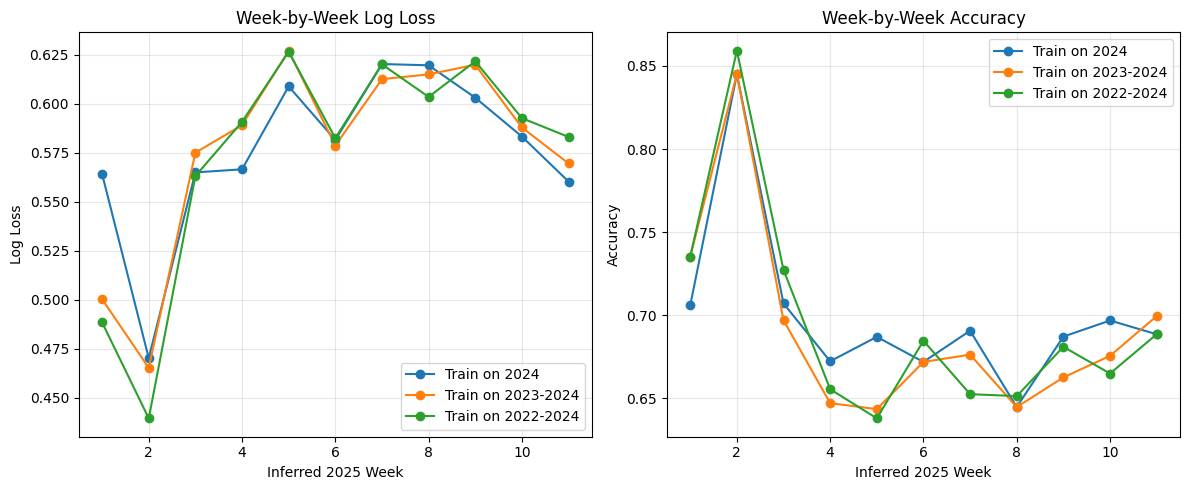

In [4]:
# ==========================================================
# 10. PLOT WEEK-BY-WEEK LOG LOSS
# ==========================================================
plt.figure(figsize=(12, 5))

# ---- LOG LOSS ----
plt.subplot(1, 2, 1)

for name, res in all_results.items():
    wk = weekly_metrics(res)
    plt.plot(
        wk["Week"].to_numpy()[:11],
        wk["log_loss"].to_numpy()[:11],
        marker="o",
        label=name
    )

plt.xlabel("Inferred 2025 Week")
plt.ylabel("Log Loss")
plt.title("Week-by-Week Log Loss")
plt.grid(True, alpha=0.3)
plt.legend()


# ---- ACCURACY ----
plt.subplot(1, 2, 2)

for name, res in all_results.items():
    wk = weekly_metrics(res)
    plt.plot(
        wk["Week"].to_numpy()[:11],
        wk["accuracy"].to_numpy()[:11],
        marker="o",
        label=name
    )

plt.xlabel("Inferred 2025 Week")
plt.ylabel("Accuracy")
plt.title("Week-by-Week Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()